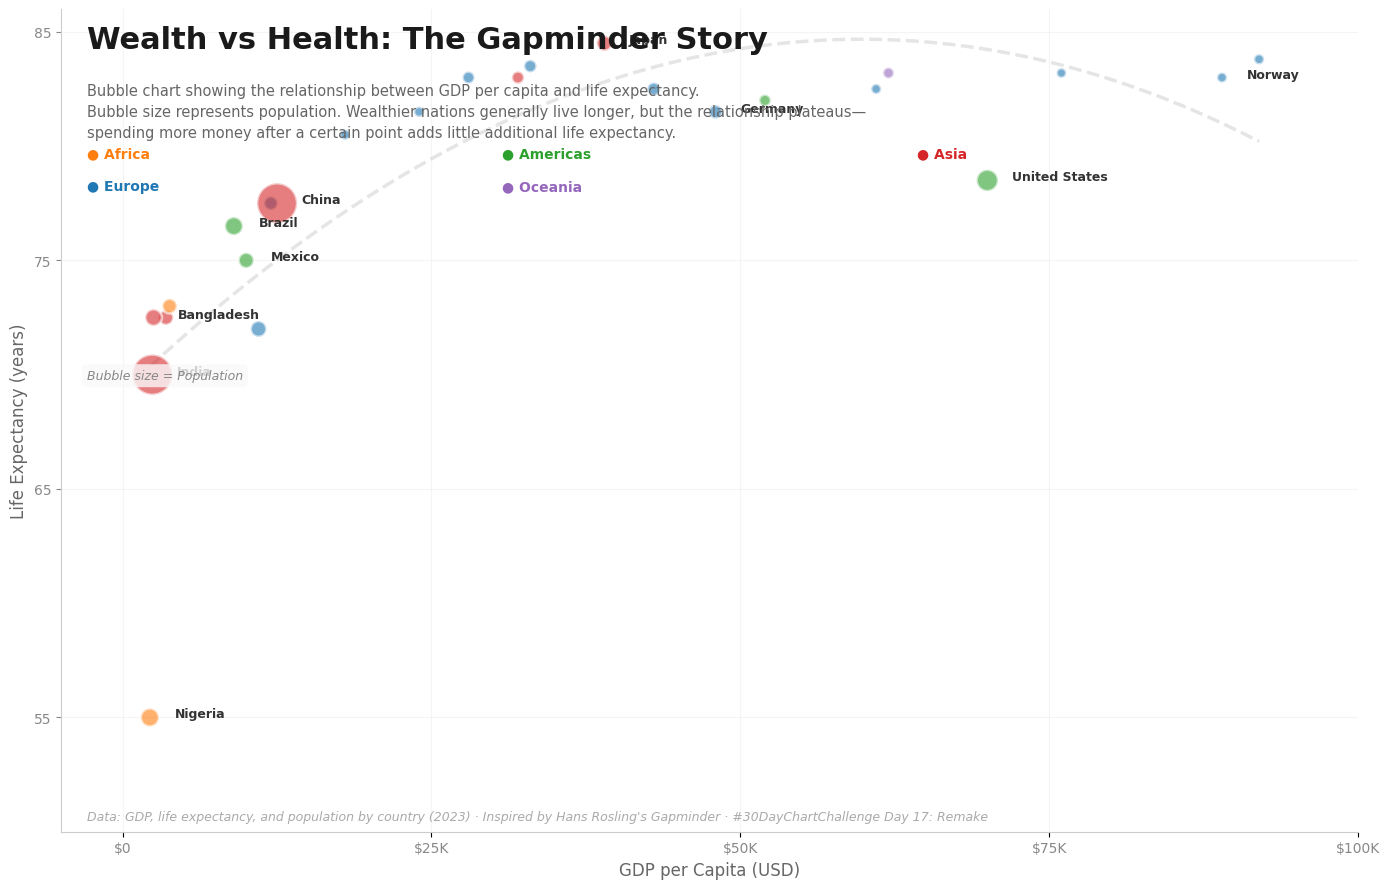

In [3]:
"""
#30DayChartChallenge — Day 17: Remake
"Wealth vs Health: A Modern Gapminder" — remaking a classic visualization
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: GDP per capita vs Life expectancy by country (2023)
Inspired by Hans Rosling's famous Gapminder bubble chart
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Gapminder-style: GDP vs Life Expectancy
# ---------------------------------------------------------------------------
data = {
    "Country": [
        "Norway", "Switzerland", "Denmark", "Iceland", "Japan",
        "Australia", "Canada", "Germany", "France", "United States",
        "South Korea", "Spain", "Italy", "Greece", "Portugal",
        "Mexico", "Brazil", "Turkey", "China", "Russia",
        "India", "Philippines", "Egypt", "Nigeria", "Bangladesh"
    ],
    "GDP_per_Capita": [
        89000, 92000, 61000, 76000, 39000,
        62000, 52000, 48000, 43000, 70000,
        32000, 28000, 33000, 18000, 24000,
        10000, 9000, 12000, 12500, 11000,
        2400, 3500, 3800, 2200, 2500
    ],
    "Life_Expectancy": [
        83.0, 83.8, 82.5, 83.2, 84.5,
        83.2, 82.0, 81.5, 82.5, 78.5,
        83.0, 83.0, 83.5, 80.5, 81.5,
        75.0, 76.5, 77.5, 77.5, 72.0,
        70.0, 72.5, 73.0, 55.0, 72.5
    ],
    "Population": [
        5.5, 8.7, 5.9, 0.4, 125,
        26, 39, 84, 68, 340,
        52, 48, 57, 10.5, 10,
        130, 215, 85, 1400, 145,
        1420, 115, 110, 220, 170
    ],
    "Region": [
        "Europe", "Europe", "Europe", "Europe", "Asia",
        "Oceania", "Americas", "Europe", "Europe", "Americas",
        "Asia", "Europe", "Europe", "Europe", "Europe",
        "Americas", "Americas", "Europe", "Asia", "Europe",
        "Asia", "Asia", "Africa", "Africa", "Asia"
    ]
}

df = pd.DataFrame(data)

# ---------------------------------------------------------------------------
# 2. PLOT — Bubble chart (Gapminder style)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Color by region
region_colors = {
    "Europe": "#1f77b4",
    "Asia": "#d62728",
    "Americas": "#2ca02c",
    "Africa": "#ff7f0e",
    "Oceania": "#9467bd"
}

colors = [region_colors[r] for r in df["Region"]]

# Bubble sizes based on population
sizes = (df["Population"] / df["Population"].max() * 800 + 50)

# Create scatter plot
scatter = ax.scatter(df["GDP_per_Capita"], df["Life_Expectancy"],
                     s=sizes, c=colors, alpha=0.6, edgecolor="white", linewidth=2, zorder=3)

# Labels for selected countries (avoid clutter)
label_countries = ["Norway", "United States", "China", "India", "Nigeria", 
                   "Brazil", "Japan", "Germany", "Mexico", "Bangladesh"]

for idx, row in df.iterrows():
    if row["Country"] in label_countries:
        ax.text(row["GDP_per_Capita"] + 2000, row["Life_Expectancy"],
                row["Country"], fontsize=9, fontweight="600", color="#333333")

# Add trend line
z = np.polyfit(df["GDP_per_Capita"], df["Life_Expectancy"], 2)
p = np.poly1d(z)
x_line = np.linspace(df["GDP_per_Capita"].min(), df["GDP_per_Capita"].max(), 200)
ax.plot(x_line, p(x_line), color="#cccccc", linewidth=2.5, alpha=0.5, linestyle="--", zorder=1, label="Trend")

# Axes formatting
ax.set_xlabel("GDP per Capita (USD)", fontsize=12, color="#666666", fontweight="500")
ax.set_ylabel("Life Expectancy (years)", fontsize=12, color="#666666", fontweight="500")
ax.set_xlim(-5000, 100000)
ax.set_ylim(50, 86)

# Minimal styling
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax.set_axisbelow(True)

# Format x-axis as currency
ax.set_xticks([0, 25000, 50000, 75000, 100000])
ax.set_xticklabels(["$0", "$25K", "$50K", "$75K", "$100K"], fontsize=10, color="#888888")
ax.set_yticks([55, 65, 75, 85])

# Apply tick styling
ax.tick_params(colors="#888888", labelsize=10, axis="y")

# Title & subtitle
ax.text(0.02, 0.98, "Wealth vs Health: The Gapminder Story",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.91,
        "Bubble chart showing the relationship between GDP per capita and life expectancy.\n"
        "Bubble size represents population. Wealthier nations generally live longer, but the relationship plateaus—\n"
        "spending more money after a certain point adds little additional life expectancy.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Legend
legend_y = 0.82
for i, (region, color) in enumerate(sorted(region_colors.items())):
    ax.text(0.02 + (i % 3) * 0.32, legend_y - (i // 3) * 0.04, f"● {region}",
            fontsize=10, color=color, transform=ax.transAxes, fontweight="600")

# Note about bubble size
ax.text(0.02, 0.55, "Bubble size = Population",
        fontsize=9, color="#888888", transform=ax.transAxes, style="italic",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f9", edgecolor="none", alpha=0.8))

# Source
ax.text(0.02, 0.01,
        "Data: GDP, life expectancy, and population by country (2023) · Inspired by Hans Rosling's Gapminder · #30DayChartChallenge Day 17: Remake",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day17_remake.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()